ARTI308 - Machine Learning

# Lab 4 Assignment — Solution: Data Quality Assessment & Preprocessing
## Applied to the Telco Customer Churn Dataset

Same techniques as the lab, applied to `WA_Fn-UseC_-Telco-Customer-Churn.csv`.

- **Task 1** — Find data quality issues
- **Task 2** — Handle missing values
- **Task 3** — Detect outliers (IQR)
- **Task 4** — Normalize (Min-Max & Z-score)
- **Task 5** — PCA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.shape

(7043, 21)

---
## Task 1 — Identify Data Quality Issues

Check data types, missing values, duplicates, and odd encodings.

In [1]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents            object
tenure                int64
PhoneService          object
MultipleLines         object
InternetService       object
OnlineSecurity        object
OnlineBackup          object
DeviceProtection      object
TechSupport           object
StreamingTV           object
StreamingMovies       object
Contract              object
PaperlessBilling      object
PaymentMethod         object
MonthlyCharges       float64
TotalCharges          object   <-- should be numeric!
Churn                 object
dtype: object

**Issue #1:** `TotalCharges` is text, but it should be a number.

In [1]:
df.isna().sum().sum()

0

**Issue #2:** `isna()` says zero missing values — but that's misleading. The missing values are **empty strings `' '`**, not `NaN`, so this check misses them.

In [1]:
blanks = df['TotalCharges'].str.strip() == ''
print("Rows with blank TotalCharges:", blanks.sum())
df.loc[blanks, ['customerID','tenure','MonthlyCharges','TotalCharges']]

Rows with blank TotalCharges: 11

     customerID  tenure  MonthlyCharges TotalCharges
488  4472-LVYGI       0           52.55
753  3115-CZMZD       0           20.25
936  5709-LVOEQ       0           80.85
1082 4367-NUYAO       0           25.75
1340 1371-DWPAZ       0           56.05
3331 7644-OMVMY       0           19.85
3826 3213-VVOLG       0           25.35
4380 2520-SGTTA       0           20.00
5218 2923-ARZLG       0           19.70
6670 4075-WKNIU       0           73.35
6754 2775-SEFEE       0           61.90

All 11 rows have `tenure = 0` — brand-new customers who haven't been billed yet, which explains the blanks.

In [1]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated customerID values:", df['customerID'].duplicated().sum())
print("Unique SeniorCitizen values:", df['SeniorCitizen'].unique())

Fully duplicated rows: 0
Duplicated customerID values: 0
Unique SeniorCitizen values: [0 1]

### Summary
1. `TotalCharges` — wrong type (text, not numeric)
2. `TotalCharges` — 11 hidden missing values (blank strings)
3. `SeniorCitizen` — stored as 0/1, really a Yes/No category
4. No duplicate rows or IDs — that part is clean

---
## Task 2 — Handle Missing Values

First, convert `TotalCharges` to numeric. The blank strings become real `NaN`.

In [1]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isna().sum()

11

**Strategy: fill with 0, not mean/median.**

Why: these customers all have `tenure = 0` — they're brand new and haven't been billed. Their true total is 0, not the average of everyone else (~$2279). Filling with the mean would invent a value that makes no sense for a new customer.

In [1]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['TotalCharges'].isna().sum()

0

---
## Task 3 — Outliers (IQR)

Apply the IQR rule to `tenure`, `MonthlyCharges`, `TotalCharges`.

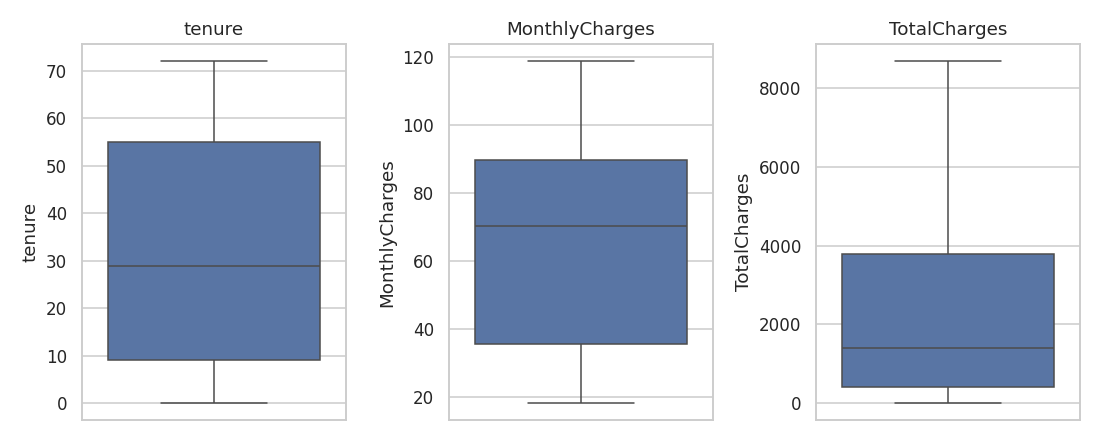

In [1]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(10,4))
for i, c in enumerate(num_cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[c])
    plt.title(c)
plt.tight_layout()
plt.show()

In [1]:
outlier_summary = {}
mask_all = pd.Series(True, index=df.index)

for c in num_cols:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    out = df[(df[c] < lower) | (df[c] > upper)]
    outlier_summary[c] = {"lower": round(lower,2), "upper": round(upper,2), "count": len(out)}
    mask_all &= (df[c] >= lower) & (df[c] <= upper)

outlier_summary

{'tenure': {'lower': -60.0, 'upper': 124.0, 'count': 0},
 'MonthlyCharges': {'lower': -46.02, 'upper': 171.38, 'count': 0},
 'TotalCharges': {'lower': -4683.53, 'upper': 8868.68, 'count': 0}}

In [1]:
df_no_outliers = df[mask_all]
df.shape, df_no_outliers.shape

((7043, 21), (7043, 21))

**No outliers found.** These columns are naturally bounded — `tenure` only goes 0 to 72 months, charges stay in a normal range. Not every dataset has outliers; IQR is still worth checking.

---
## Task 4 — Normalize: Min-Max & Z-score

### Min-Max

In [1]:
scaler_mm = MinMaxScaler()
df_minmax = df[num_cols].copy()
df_minmax[num_cols] = scaler_mm.fit_transform(df_minmax)
df_minmax.describe().loc[['min','max']]

        tenure  MonthlyCharges  TotalCharges
min        0.0             0.0           0.0
max        1.0             1.0           1.0

### Z-score

In [1]:
scaler_z = StandardScaler()
df_z = df[num_cols].copy()
df_z[num_cols] = scaler_z.fit_transform(df_z)
df_z.mean().round(3), df_z.std().round(3)

(tenure            -0.0
MonthlyCharges     -0.0
TotalCharges       -0.0
dtype: float64,
 tenure             1.0
MonthlyCharges      1.0
TotalCharges        1.0
dtype: float64)

**Min-Max** → fixed [0,1] range, good for neural nets. **Z-score** → centered at 0, needed for PCA (used next).

### Correlation Before PCA

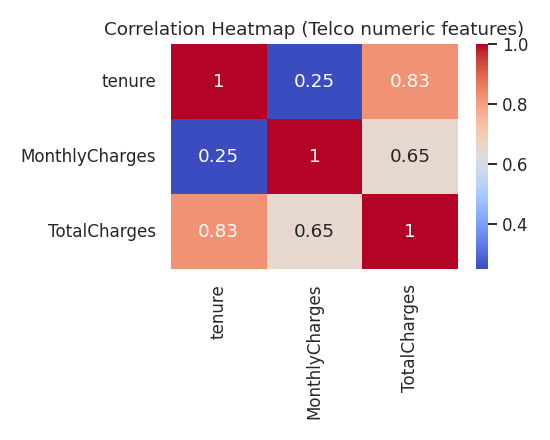

In [1]:
plt.figure(figsize=(5,4))
sns.heatmap(df_z.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Telco numeric features)")
plt.tight_layout()
plt.show()

`tenure` and `TotalCharges` are strongly correlated (≈0.83) — they overlap in information, which is exactly when PCA helps.

---
## Task 5 — PCA

In [1]:
pca = PCA(n_components=3)
principal_components = pca.fit_transform(df_z)

print("Explained Variance Ratio:", pca.explained_variance_ratio_.round(4))
print("Cumulative Variance:", np.cumsum(pca.explained_variance_ratio_).round(4))

Explained Variance Ratio: [0.7269 0.2533 0.0199]
Cumulative Variance: [0.7269 0.9801 1.    ]

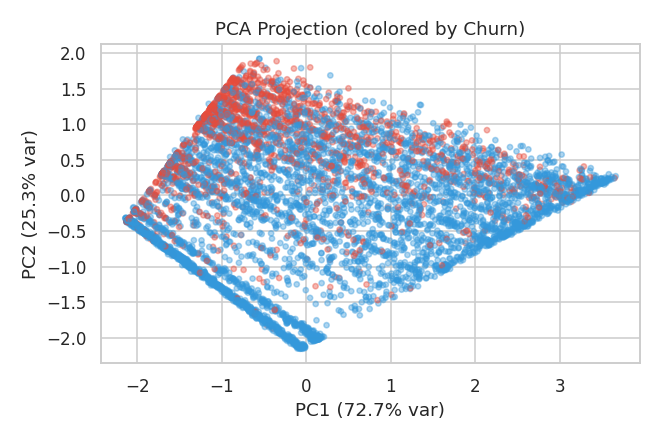

In [1]:
plt.figure(figsize=(6,4))
colors = df['Churn'].map({'Yes': '#e74c3c', 'No': '#3498db'})
plt.scatter(principal_components[:,0], principal_components[:,1], c=colors, alpha=0.4, s=12)
plt.title("PCA Projection (colored by Churn)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.show()

### Interpretation
- **PC1** = 72.7% of the variance (mostly the tenure/spend pattern)
- **PC2** = another 25.3% → PC1+PC2 together = **98%**
- **PC3** ≈ 2% → safe to drop

**Takeaway:** 3 features can be reduced to 2 with almost no information lost. In the plot, churned (red) and retained (blue) customers overlap a lot, so these 3 numeric features alone don't fully separate churn — contract type and payment method would help more.